# 2. Machine Learning for Regression

In [2]:
import pandas as pd
import numpy as np

## 2.2 Data preparation

In [3]:
data = 'https://github.com/alexeygrigorev/mlbookcamp-code/blob/master/chapter-02-car-price/data.csv'

In [4]:
!wget $data

--2026-05-18 07:49:05--  https://github.com/alexeygrigorev/mlbookcamp-code/blob/master/chapter-02-car-price/data.csv
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘data.csv’

data.csv                [ <=>                ] 226.31K  --.-KB/s    in 0.1s    

2026-05-18 07:49:06 (2.18 MB/s) - ‘data.csv’ saved [231746]



In [6]:
df = pd.read_csv('/content/data.csv')

In [7]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [8]:
df.dtypes == 'object'

,0
make,True
model,True
year,False
engine_fuel_type,True
engine_hp,False
engine_cylinders,False
transmission_type,True
driven_wheels,True
number_of_doors,False
market_category,True


In [9]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [10]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [11]:
df.head(10)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


## 2.3 Exploratory data analysis

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

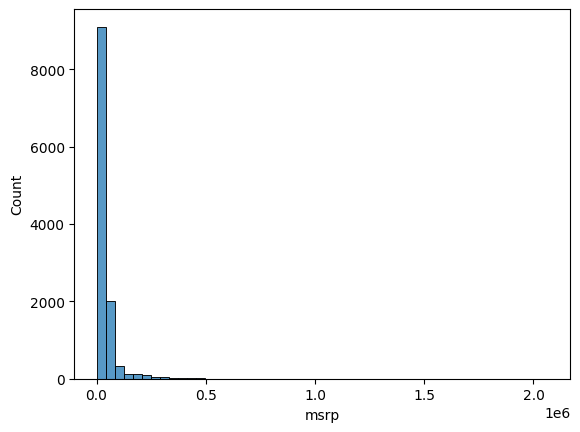

In [13]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

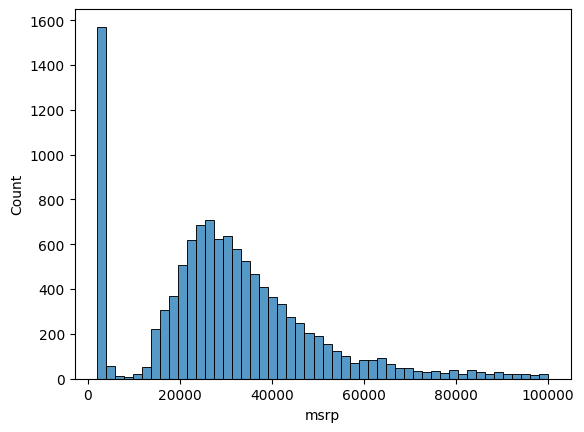

In [14]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [15]:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [16]:
np.log1p([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100000])

array([ 0.69314718,  1.09861229,  2.48490665,  6.90975328, 11.51293546])

In [17]:
price_logs = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

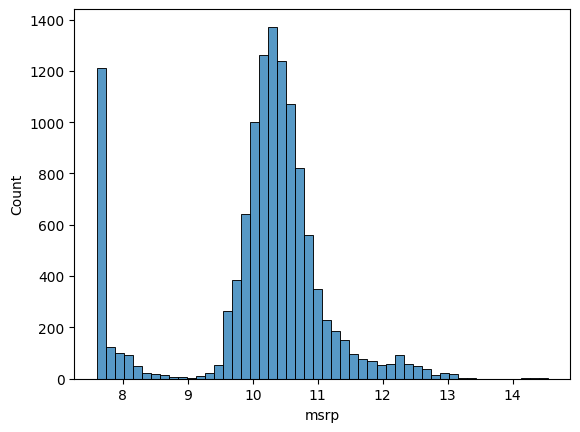

In [18]:
sns.histplot(price_logs, bins=50)

In [19]:
df.isnull().sum()

,0
make,0
model,0
year,0
engine_fuel_type,3
engine_hp,69
engine_cylinders,30
transmission_type,0
driven_wheels,0
number_of_doors,6
market_category,3742


## 2.4 Setting up the validation framework

In [20]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [21]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [22]:
df.iloc[[10, 0, 3, 5]]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
10,bmw,1_series,2013,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39600
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200


In [23]:
df_train = df.iloc[n_train : ]
df_val = df.iloc[n_train : n_train + n_val]
df_test = df.iloc[n_train + n_val : ]

In [24]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7150,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,63645
7151,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,22,16,61,63195
7152,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,76650
7153,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,69135
7154,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [25]:
idx = np.arange(n)

In [26]:
np.random.seed(2)
np.random.shuffle(idx)

In [27]:
df_train = df.iloc[idx[ : n_train]]
df_val = df.iloc[idx[n_train : n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val : ]]

In [28]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [29]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [30]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [31]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [32]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [33]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [34]:
len(y_train)

7150

## 2.5 Linear Regression

In [35]:
df_train.iloc[10]

,10
make,rolls-royce
model,phantom_drophead_coupe
year,2015
engine_fuel_type,premium_unleaded_(required)
engine_hp,453.0
engine_cylinders,12.0
transmission_type,automatic
driven_wheels,rear_wheel_drive
number_of_doors,2.0
market_category,"exotic,luxury,performance"


In [36]:
xi = [453, 11, 86]

In [37]:
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [38]:
def linear_regression(xi):
  n = len(xi)

  pred = w0

  for j in range(n):
    pred = pred + w[j] * xi[j]

  return pred

In [39]:
linear_regression(xi)

12.312

In [40]:
np.expm1(12.312)

np.float64(222347.2221101062)

In [41]:
np.log1p(222347.2221101062)

np.float64(12.312)

## 2.6 Linear regression vector

In [42]:
def dot(xi, w):
  n = len(xi)
  res = 0

  for j in range(n):
    res = res  + xi[j] * w[j]

  return res

In [43]:
def linear_regression(xi):
  return w0 + dot(xi, w)

In [44]:
w_new = [w0] + w

In [45]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [46]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [47]:
linear_regression(xi)

12.312

In [48]:
xi = [453, 11, 86]
w0 = 7.17
W = [0.01, 0.04, 0.002]

In [49]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [50]:
def linear_regression(X):
  return X.dot(w_new)

In [51]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

## 2.7 Training a linear regression model

In [52]:
def train_linear_regression(X, y):
    pass

In [53]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38, 54, 185],
    [142, 25, 431],
    [453, 31, 86]
]
X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [54]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [55]:
X = np.column_stack([ones, X])

In [56]:
y = [10000, 20000, 15000, 25000, 10000, 20000, 15000, 25000, 12000]

In [57]:
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)

In [58]:
w0 = w_full[0]
w = w_full[1:]

In [59]:
w0, w

(np.float64(30006.77669255554),
 array([ -22.77425287, -257.69412959,   -2.3012064 ]))

In [60]:
def train_linear_regression(X, y):
  ones = np.ones(X.shape[0])
  X = np.column_stack([ones, X])

  XTX = X.T.dot(X)
  XTX_inv = np.linalg.inv(XTX)
  w_full = XTX_inv.dot(X.T).dot(y)

  return w_full[0], w_full[1:]

In [61]:
train_linear_regression(X[:, 1:], y)

(np.float64(30006.77669255554),
 array([ -22.77425287, -257.69412959,   -2.3012064 ]))

Found error: <br>
The LinAlgError: Singular matrix is happening because your feature matrix X has linearly dependent columns. Specifically, the X you're passing to train_linear_regression already includes a column of ones for the intercept, but the train_linear_regression function then adds another column of ones. This results in two identical columns, making the matrix singular.

## 2.8 Car price baseline model

In [62]:
df_train.dtypes

,0
make,object
model,object
year,int64
engine_fuel_type,object
engine_hp,float64
engine_cylinders,float64
transmission_type,object
driven_wheels,object
number_of_doors,float64
market_category,object


In [63]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [64]:
X_train = df_train[base].values

In [65]:
df_train[base].fillna(0)

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657
...,...,...,...,...,...
7145,300.0,6.0,31,20,3916
7146,210.0,4.0,30,24,873
7147,285.0,6.0,22,17,549
7148,563.0,12.0,21,13,86


In [66]:
w0, w = train_linear_regression(X_train, y_train)

In [67]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

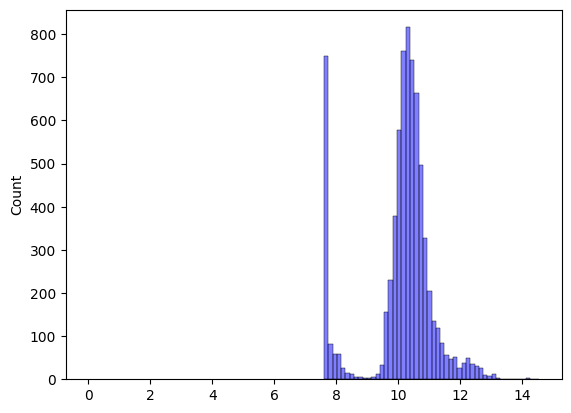

In [68]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

## 2.9 Root Mean Squared Error (RMSE)

In [69]:
def rmse(y, y_pred):
  se = (y - y_pred) ** 2
  mse = se.mean()
  return np.sqrt(mse)

In [70]:
rmse(y_train, y_pred)

np.float64(nan)

## 2.10 Validating the model

In [71]:
X_train = df_train[base].fillna(0).values

In [72]:
w0, w = train_linear_regression(X_train, y_train)

In [73]:
y_pred = w0 + X_train.dot(w)

In [74]:
def prepare_X(df):
  df_num = df[base]
  df_num = df_num.fillna(0)
  X = df_num.values
  return X

In [75]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_train.dot(w)

In [76]:
y_val

array([10.19936098, 10.90872279,  9.72770457, ..., 11.21756062,
        9.77542688, 10.1924563 ])

In [77]:
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111])

In [78]:
y_pred_val = w0 + X_val.dot(w)
rmse(y_val, y_pred_val)

np.float64(0.761653099130156)

Error found: <br>
The error is due to a shape mismatch between y_val and y_pred. y_val contains 2382 elements, but y_pred has 7150 elements. This means y_pred was incorrectly calculated using the training data (X_train) instead of the validation data (X_val). To resolve this, y_pred for the validation set needs to be computed using X_val.

## 2.11 Simple feature engineering

In [79]:
2017 - df_train.year

,year
0,9
1,5
2,1
3,26
4,0
...,...
7145,2
7146,2
7147,2
7148,3


In [80]:
def prepare_X(df):
  df['age'] = 2017 - df.year
  features = base + ['age']

  df_num = df[features]
  df_num = df_num.fillna(0)
  X = df_num.values
  return X

In [81]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

<Axes: ylabel='Count'>

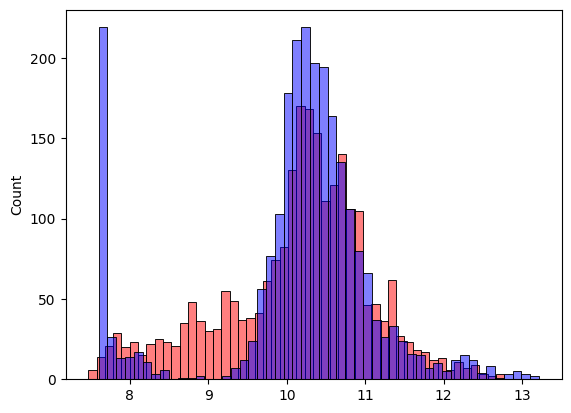

In [82]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

## 2.12 Categorical variables

In [83]:
df_train.dtypes

,0
make,object
model,object
year,int64
engine_fuel_type,object
engine_hp,float64
engine_cylinders,float64
transmission_type,object
driven_wheels,object
number_of_doors,float64
market_category,object


In [84]:
for v in [2, 3, 4]:
  df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')

In [85]:
def prepare_X(df):
  df = df.copy()
  features = base.copy()

  df['age'] = 2017 - df.year
  features.append('age')

  for v in [2, 3, 4]:
      df['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')
      features.append('num_doors_%s' % v)

  df_num = df[features]
  df_num =  df_num.fillna(0)
  X = df_num.values

  return X

In [86]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

Found error: <br>
The error is occurring because the weight vector w you're using has a different number of elements (6) than the number of features in X_val (9). You should be using w1, which correctly contains 9 weights matching the 9 features in X_val after the prepare_X function has added the 'age' and 'num_doors' features.

In [110]:
makes = list(df.make.value_counts().head().index)

In [111]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for v in makes:
        df['make_%s' % v] = (df.make ==  v).astype('int')
        features.append('make_%s' % v)

    df_num = df[features]
    df_num =  df_num.fillna(0)
    X = df_num.values

    return X

In [112]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5107406267035234)

In [113]:
categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

In [114]:
categories = {}

for c in categorical_variables:
  categories[c] = list(df[c].value_counts().head().index)

In [115]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [116]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] ==  v).astype('int')
            features.append('%s_%s' % (c, v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [117]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(39.08087777605988)

In [118]:
w0, w

(np.float64(4011091003551887.0),
 array([ 5.17477261e-02,  5.87434156e+00,  2.58988500e+00, -9.14739385e-01,
         3.29434090e-03,  1.26747065e+00,  1.09365186e+03,  1.08197230e+03,
         1.08519232e+03, -2.94630727e+00, -7.48076191e+00,  1.02357603e+01,
        -8.56657044e-01, -2.27736086e+00,  1.84973907e+00, -3.51656880e+00,
        -2.20958315e+00,  6.07018281e+00, -3.32427158e+01, -4.60060984e+15,
        -4.60060984e+15, -4.60060984e+15, -4.60060984e+15, -4.60060984e+15,
         5.89518839e+14,  5.89518839e+14,  5.89518839e+14,  5.89518839e+14,
        -9.26775404e-01,  3.51631589e-01,  1.80584944e-01,  1.46169331e+00,
        -1.67201746e+00, -3.59104780e+00, -6.16304692e+00, -5.45706022e+00,
        -4.85492239e-02,  5.44797374e-02,  1.78241160e-01,  3.41906701e-01,
        -1.64412078e-01]))

## 2.13 Regularization

In [119]:
x = [
     [4, 4, 4],
     [3, 5, 5],
     [5, 1, 1],
     [5, 4, 4],
     [7, 5, 5],
     [4, 5, 5.00001],
]

In [120]:
X = np.array(x)
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])

In [121]:
y = [1, 2, 3, 1, 2, 3]

In [122]:
XTX = X.T.dot(X)

In [123]:
XTX_inv = np.linalg.inv(XTX)

In [124]:
XTX_inv.dot(X.T).dot(y)

array([ 2.51684813e+00,  8.40687525e-02, -1.62163327e+05,  1.62163032e+05])

Found error: <br>
The error is due to a shape mismatch during matrix multiplication. The X matrix used to calculate XTX_inv and X.T has 9 rows, but the y vector you're trying to multiply with has only 6 elements.

In [125]:
XTX = [
       [1, 2, 2],
       [2, 1, 1.00001],
       [2, 1.00001, 1]
]
XTX = np.array(XTX)
XTX

array([[1.     , 2.     , 2.     ],
       [2.     , 1.     , 1.00001],
       [2.     , 1.00001, 1.     ]])

In [126]:
np.linalg.inv(XTX)

array([[-3.33335556e-01,  3.33333889e-01,  3.33333889e-01],
       [ 3.33333889e-01, -5.00000833e+04,  4.99999167e+04],
       [ 3.33333889e-01,  4.99999167e+04, -5.00000833e+04]])

In [127]:
XTX = XTX + 0.01 * np.eye(3)

In [128]:
np.linalg.inv(XTX)

array([[ -0.3366913 ,   0.33501455,   0.33501455],
       [  0.33501455,  49.96545888, -50.13464122],
       [  0.33501455, -50.13464122,  49.96545888]])

In [129]:
def train_linear_regression_t1(X, y, r=0.001):
  ones = np.ones(X.shape[0])
  X = np.column_stack([ones, X])

  XTX = X.T.dot(X)
  XTX = XTX + r * np.eye(XTX.shape[0])

  XTX_inv = np.linalg.inv(XTX)
  w_full = XTX_inv.dot(X.T).dot(y)

  return w_full[0], w_full[1:]

In [130]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_t1(X_train, y_train, r=0.001)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.4708556220464049)

## 2.14 Tunning the model

In [131]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.01, 1, 10]:
  x_train =  prepare_X(df_train)
  w0, w = train_linear_regression_t1(X_train, y_train, r=r)

  X_val = prepare_X(df_val)
  y_pred = w0 + X_val.dot(w)
  score = rmse(y_val, y_pred)

  print(r, w0, score)

0.0 4011091003551887.0 39.08087777605988
1e-05 6.178192055025445 0.47085641095229397
0.0001 6.317246071243372 0.47085630477750834
0.001 6.285636717989048 0.4708556220464049
0.01 6.2766071476973995 0.4708490233625762
1 5.634896668066369 0.47181888777670644
10 4.283980108968471 0.4888174228177475


In [132]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_t1(X_train, y_train, r=0.001)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.4708556220464049)

## 2.15 Using the model

In [133]:
df_full_train = pd.concat([df_train, df_val])

In [134]:
df_full_train = df_full_train.reset_index(drop=True)

In [135]:
X_full_train = prepare_X(df_full_train)

In [136]:
X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]])

In [137]:
y_full_train = np.concatenate([y_train, y_val])

In [138]:
w0, w = train_linear_regression_t1(X_full_train, y_full_train, r=0.001)

In [139]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.45718619941265004)

In [140]:
car = df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [141]:
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [143]:
X_small = prepare_X(df_small)

In [144]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(10.367598334123727)

In [145]:
np.expm1(y_pred)

np.float64(31810.98339562599)

In [146]:
np.expm1(y_test[20])

np.float64(35000.00000000001)

## 2.16 Summary